
# Aula Prática — Feature Encoding em Machine Learning

## Objetivo

Nesta aula prática iremos aprender como transformar variáveis categóricas em números para algoritmos de Machine Learning.

Técnicas abordadas:

- Label Encoding
- One Hot Encoding
- Dummy Encoding
- Frequency Encoding
- Count Encoding
- Target Encoding
- Hash Encoding
- Embeddings Encoding


![ChatGPT Image 24 de mai. de 2026, 08_58_38.png](<attachment:ChatGPT Image 24 de mai. de 2026, 08_58_38.png>)
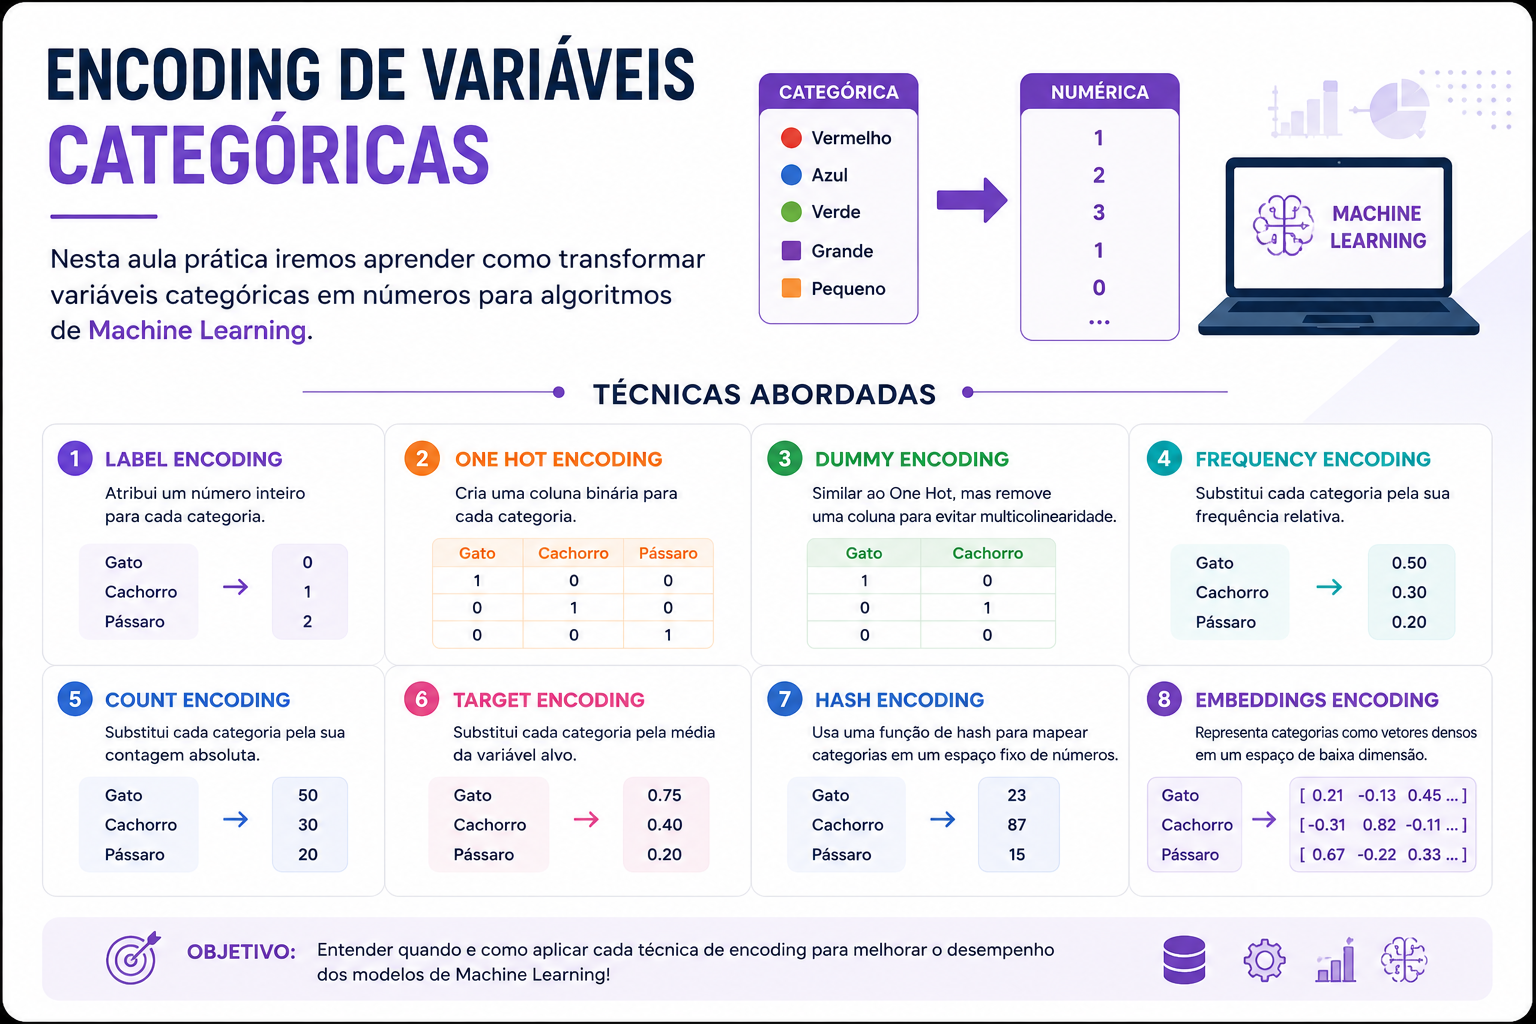

In [1]:

import pandas as pd

# Base de dados exemplo
df = pd.DataFrame({
    'cidade': ['SP', 'RJ', 'MG', 'SP', 'RJ', 'SP'],
    'profissao': ['Engenheiro', 'Médico', 'Professor', 'Professor', 'Médico', 'Engenheiro'],
    'sexo': ['M', 'F', 'F', 'M', 'F', 'M'],
    'salario': [8000, 12000, 5000, 6000, 11000, 7500],
    'comprou': [1, 1, 0, 0, 1, 1]
})

df


,cidade,profissao,sexo,salario,comprou
0,SP,Engenheiro,M,8000,1
1,RJ,Médico,F,12000,1
2,MG,Professor,F,5000,0
3,SP,Professor,M,6000,0
4,RJ,Médico,F,11000,1
5,SP,Engenheiro,M,7500,1



# 1. Label Encoding

Transforma categorias em números inteiros.


In [2]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['cidade_label'] = le.fit_transform(df['cidade'])

df[['cidade', 'cidade_label']]


,cidade,cidade_label
0,SP,2
1,RJ,1
2,MG,0
3,SP,2
4,RJ,1
5,SP,2



# 2. One Hot Encoding

Cria uma coluna para cada categoria.


In [3]:

one_hot = pd.get_dummies(df['cidade'])

one_hot


,MG,RJ,SP
0,False,False,True
1,False,True,False
2,True,False,False
3,False,False,True
4,False,True,False
5,False,False,True



# 3. Dummy Encoding

Semelhante ao One Hot Encoding, porém remove uma coluna para evitar multicolinearidade.


In [4]:

dummy = pd.get_dummies(df['cidade'], drop_first=True)

dummy


,RJ,SP
0,False,True
1,True,False
2,False,False
3,False,True
4,True,False
5,False,True



# 4. Frequency Encoding

Substitui categorias pela frequência percentual.


In [5]:

freq = df['cidade'].value_counts(normalize=True)

df['cidade_freq'] = df['cidade'].map(freq)

df[['cidade', 'cidade_freq']]


,cidade,cidade_freq
0,SP,0.500000
1,RJ,0.333333
2,MG,0.166667
3,SP,0.500000
4,RJ,0.333333
5,SP,0.500000



# 5. Count Encoding

Substitui categorias pela contagem absoluta.


In [6]:

count = df['cidade'].value_counts()

df['cidade_count'] = df['cidade'].map(count)

df[['cidade', 'cidade_count']]


,cidade,cidade_count
0,SP,3
1,RJ,2
2,MG,1
3,SP,3
4,RJ,2
5,SP,3



# 6. Target Encoding

Substitui categorias pela média da variável alvo.


In [7]:

target = df.groupby('cidade')['comprou'].mean()

df['cidade_target'] = df['cidade'].map(target)

df[['cidade', 'cidade_target']]


,cidade,cidade_target
0,SP,0.666667
1,RJ,1.000000
2,MG,0.000000
3,SP,0.666667
4,RJ,1.000000
5,SP,0.666667



# 7. Hash Encoding

Utiliza funções hash para representar categorias.


In [8]:

# Instalar caso necessário
# !pip install category_encoders

import category_encoders as ce

hash_encoder = ce.HashingEncoder(cols=['profissao'], n_components=4)

hash_data = hash_encoder.fit_transform(df)

hash_data.head()


,col_0,col_1,col_2,col_3,cidade,sexo,salario,comprou,cidade_label,cidade_freq,cidade_count,cidade_target
0,0,1,0,0,SP,M,8000,1,2,0.500000,3,0.666667
1,1,0,0,0,RJ,F,12000,1,1,0.333333,2,1.000000
2,1,0,0,0,MG,F,5000,0,0,0.166667,1,0.000000
3,1,0,0,0,SP,M,6000,0,2,0.500000,3,0.666667
4,1,0,0,0,RJ,F,11000,1,1,0.333333,2,1.000000



# 8. Embeddings Encoding

Muito utilizado em Deep Learning.


In [9]:

import tensorflow as tf
from tensorflow.keras.layers import Embedding

categorias = [0, 1, 2, 1, 0]

embedding = Embedding(input_dim=3, output_dim=2)

resultado = embedding(tf.constant(categorias))

resultado


ModuleNotFoundError: No module named 'tensorflow'


# Comparação Geral

| Encoding | Melhor Uso |
|---|---|
| Label | Árvores |
| One Hot | Regressão |
| Dummy | Regressão |
| Frequency | Big Data |
| Count | Alta cardinalidade |
| Target | Alta performance |
| Hash | NLP / Big Data |
| Embeddings | Deep Learning |



# Pipeline Completo

Exemplo real usando Scikit-Learn.


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X = df[['cidade', 'profissao', 'sexo', 'salario']]
y = df['comprou']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

cat_features = ['cidade', 'profissao', 'sexo']

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression())
])

pipeline.fit(X_train, y_train)

print('Modelo treinado com sucesso!')



# Exercício Proposto

Aplique os encodings na base abaixo:

```python
clientes = pd.DataFrame({
    'estado': ['SP', 'RJ', 'MG', 'SP', 'BA', 'RJ'],
    'produto': ['Notebook', 'Celular', 'Notebook', 'TV', 'TV', 'Celular'],
    'comprou': [1, 0, 1, 0, 1, 1]
})
```
